# GAN - 10기 최지희


## 코드 13-22 라이브러리 호출

In [1]:
import imageio  # 이미지 데이터를 읽고 쓸 수 있는 쉬운 인터페이스를 제공하는 라이브러리
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pylab as plt
import numpy as np

from torchvision.utils import make_grid, save_image
import torchvision.datasets as datasets
import torchvision.transforms as transforms
plt.style.use('ggplot')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/home/jiheechoi0102/homeworkenv/lib/python3.12/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12070). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## matplotlib 스타일시트 확인 코드

In [2]:
import matplotlib.pyplot as plt

In [3]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

## 코드 13-23 변수 값 설정

In [4]:
batch_size = 512
epochs = 50
sample_size = 64  # ①
nz = 128  # ②
k = 1  # ③

## 코드 13-24 MNIST를 내려받은 후 정규화

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),  # 이미지를 텐서로 변환
    transforms.Normalize((0.5,), (0.5,)),  # 이미지를 평균이 0.5, 표준편차가 0.5가 되도록 정규화
])

train_dataset = datasets.MNIST(
    root="./chap13/data", train=True, transform=transform, download=True)

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)

## 코드 13-25 생성자 네트워크 생성

In [6]:
class Generator(nn.Module):
    def __init__(self, nz):
        super(Generator, self).__init__()
        self.nz = nz
        self.main = nn.Sequential(
            nn.Linear(self.nz, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 784),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.main(x).view(-1, 1, 28, 28)  # 생성자 네트워크의 반환값은 '배치 크기×1×28×28'이 됩니다.

## 코드 13-26 판별자 네트워크 생성

In [7]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.n_input = 784  # 판별자의 입력 크기
        self.main = nn.Sequential(  # 판별자 역시 선형 계층과 리키렐루 활성화 함수로 구성
            nn.Linear(self.n_input, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.view(-1, 784)
        return self.main(x)  # 이미지가 진짜인지 가짜인지를 분류하는 값을 반환

## 코드 13-27 생성자와 판별자 네트워크 초기화

In [8]:
generator = Generator(nz).to(device)
discriminator = Discriminator().to(device)
print(generator)
print(discriminator)

Generator(
  (main): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (main): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


## 코드 13-28 옵티마이저와 손실 함수 정의

In [9]:
optim_g = optim.Adam(generator.parameters(), lr=0.0002)
optim_d = optim.Adam(discriminator.parameters(), lr=0.0002)

criterion = nn.BCELoss()

losses_g = []  # 매 에포크마다 발생하는 생성자 오차를 저장하기 위한 리스트형 변수
losses_d = []  # 매 에포크마다 발생하는 판별자 오차를 저장하기 위한 리스트형 변수
images = []  # 생성자에 의해 생성되는 이미지를 저장하기 위한 리스트형 변수

## 코드 13-29 생성된 이미지 저장 함수 정의

In [10]:
def save_generator_image(image, path):
    save_image(image, path)

## 코드 13-30 판별자 학습을 위한 함수

In [11]:
def train_discriminator(optimizer, data_real, data_fake):
    b_size = data_real.size(0)  # 배치 크기 정보 얻기
    real_label = torch.ones(b_size, 1).to(device)  # ①
    fake_label = torch.zeros(b_size, 1).to(device)  # ②
    optimizer.zero_grad()
    output_real = discriminator(data_real)
    loss_real = criterion(output_real, real_label)  # 진짜 데이터를 판별자에 제공하여 학습한 결과와 진짜 데이터의 레이블을 이용하여 오차를 계산
    output_fake = discriminator(data_fake)
    loss_fake = criterion(output_fake, fake_label)  # 가짜 데이터를 판별자에 제공하여 학습한 결과와 가짜 데이터의 레이블을 이용하여 오차를 계산
    loss_real.backward()
    loss_fake.backward()
    optimizer.step()
    return loss_real + loss_fake  # 진짜 데이터와 가짜 데이터의 오차가 합쳐진 최종 오차를 반환

## 코드 13-31 생성자 학습을 위한 함수

In [12]:
def train_generator(optimizer, data_fake):
    b_size = data_fake.size(0)
    real_label = torch.ones(b_size, 1).to(device)  # ①
    optimizer.zero_grad()
    output = discriminator(data_fake)
    loss = criterion(output, real_label)
    loss.backward()
    optimizer.step()
    return loss

## 코드 13-32 모델 학습

In [13]:
import os

generator.train()  # 생성자를 학습 모드로 설정
discriminator.train()  # 판별자를 학습 모드로 설정

# Create the directory for saving images if it doesn't exist
os.makedirs('./chap13/img/', exist_ok=True)

for epoch in range(epochs):
    loss_g = 0.0  # 생성자 오차를 추적(저장)하기 위한 변수
    loss_d = 0.0  # 판별자 오차를 추적(저장)하기 위한 변수
    for idx, data in tqdm(enumerate(train_loader), total=int(len(train_dataset)/train_loader.batch_size)):
        image, _ = data  # 학습을 위한 이미지 데이터를 가져옵니다.
        image = image.to(device)  # 데이터셋이 CPU/GPU 장치를 사용하도록 지정
        b_size = len(image)
        for step in range(k):  # k(1) 스텝 수에 따라 판별자를 실행. 이때 k 수를 증가시킬 수 있지만 학습 시간이 길어질 수 있으므로 주의하세요.
            data_fake = generator(torch.randn(b_size, nz).to(device)).detach()  # ①
            data_real = image
            loss_d += train_discriminator(optim_d, data_real, data_fake)  # ①′
        data_fake = generator(torch.randn(b_size, nz).to(device))
        loss_g += train_generator(optim_g, data_fake)  # 생성자 학습
        generated_img = generator(torch.randn(b_size, nz).to(device)).cpu().detach()  # 생성자를 이용하여 새로운 이미지를 생성하고 CPU 장치를 이용하여 디스크에 저장
        generated_img = make_grid(generated_img)  # 이미지를 그리드 형태로 표현
        save_generator_image(generated_img, f"./chap13/img/gen_img{epoch}.png")  # 생성된 이미지(텐서)를 디스크에 저장
        images.append(generated_img)
        epoch_loss_g = loss_g / (idx + 1)  # 에포크에 대한 총 생성자 오차 계산 (avoid division by zero)
        epoch_loss_d = loss_d / (idx + 1)  # 에포크에 대한 총 판별자 오차 계산 (avoid division by zero)
        losses_g.append(epoch_loss_g)
        losses_d.append(epoch_loss_d)

    print(f"Epoch {epoch} of {epochs}")
    print(f"Generator loss: {epoch_loss_g:.8f}, Discriminator loss: {epoch_loss_d:.8f}")

118it [00:25,  4.61it/s]                         

Epoch 0 of 50
Generator loss: 1.53081107, Discriminator loss: 0.86794645



118it [00:19,  6.07it/s]                         

Epoch 1 of 50
Generator loss: 3.08798552, Discriminator loss: 1.27654445



118it [00:18,  6.50it/s]                         

...

Epoch 47 of 50
Generator loss: 3.40368247, Discriminator loss: 0.51912868



118it [00:23,  4.98it/s]                         

Epoch 48 of 50
Generator loss: 3.31275582, Discriminator loss: 0.44216800



118it [00:23,  4.94it/s]                         

Epoch 49 of 50
Generator loss: 3.28042603, Discriminator loss: 0.44590527


## 코드 13-33 생성자와 판별자의 오차 확인

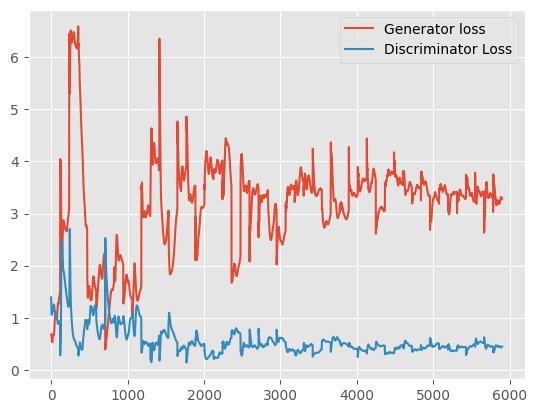

In [14]:
plt.figure()
losses_g = [f1.item() for f1 in losses_g]
plt.plot(losses_g, label='Generator loss')
losses_d = [f2.item() for f2 in losses_d]
plt.plot(losses_d, label='Discriminator Loss')
plt.legend()

## 코드 13-34 생성된 이미지 출력

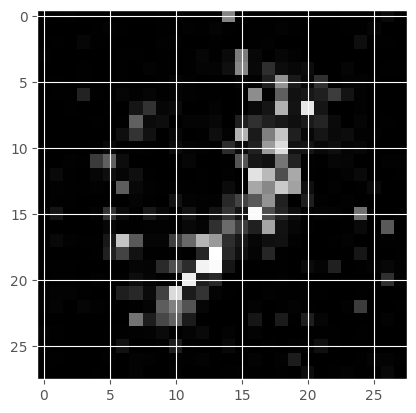

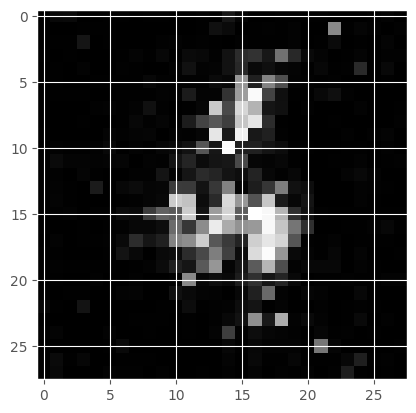

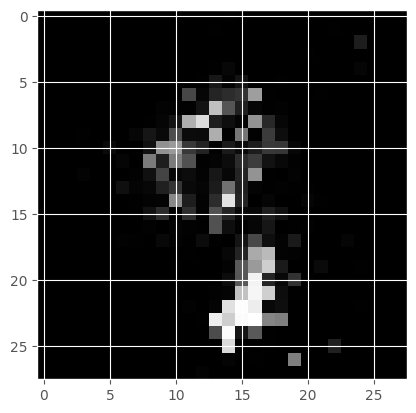

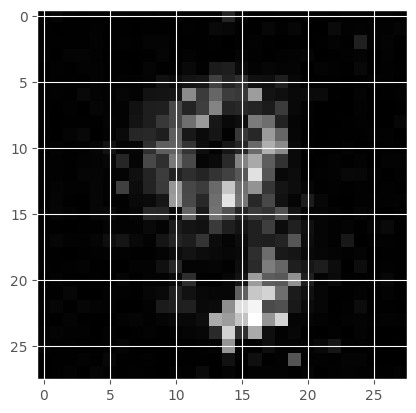

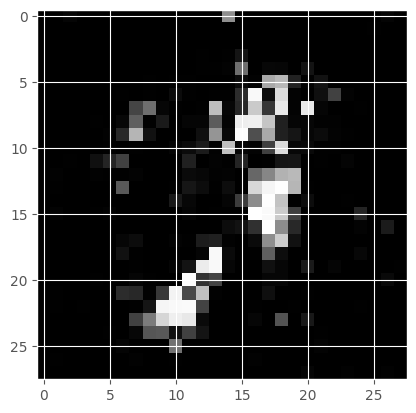

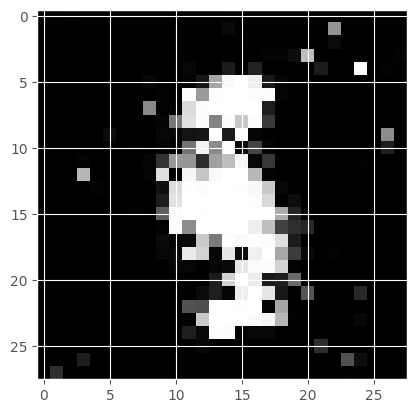

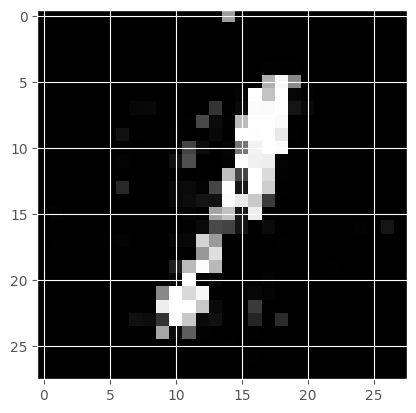

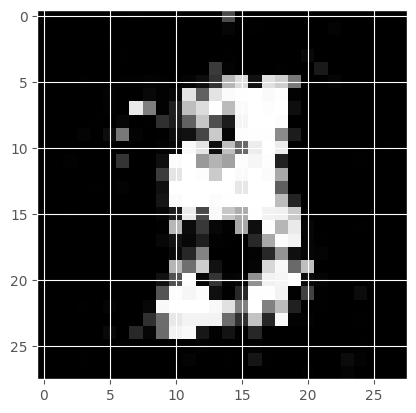

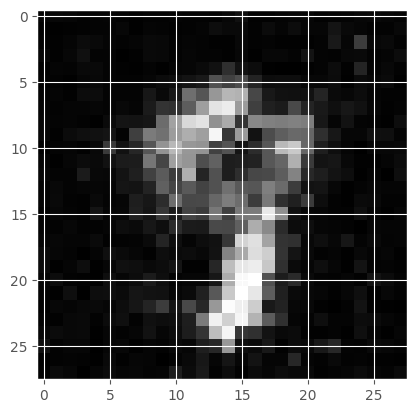

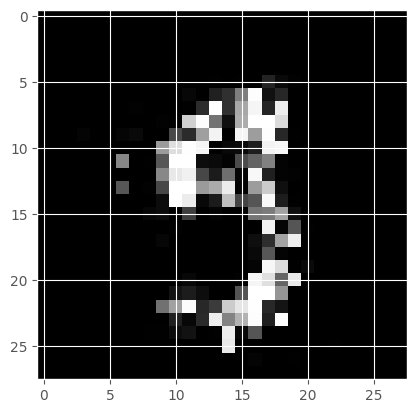

In [15]:
fake_images = generator(torch.randn(b_size, nz).to(device))
for i in range(10):
    fake_images_img = np.reshape(fake_images.data.cpu().numpy()[i], (28, 28))
    plt.imshow(fake_images_img, cmap='gray')
    plt.savefig('./chap13/img/fake_images_img' + str(i) + '.png')
    plt.show()